In [236]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

In [237]:
def print_multiple(run_dirs, labels, title="comparison"):
    """
    run_dirs: пути к папкам
    labels: подписи (["SignMuon", "Adam", "SGD"])
    metric: что выдаем ("iters_to_converge", "final_loss", )
    """
    print(title)

    for run_dir, label in zip(run_dirs, labels):
        run_dir = Path(run_dir)

        with open(run_dir / "metrics.json", "r") as f:
            data = json.load(f)

        iters_to_converge = data["iters_to_converge"]
        final_loss = data["final_loss"]


        print(label)
        print("iters_to_converge:", iters_to_converge)
        print(f"final_loss: {final_loss:.4f}")
        print('\n')

In [238]:
# def plot_multiple_histories(run_dirs, labels, metric="train_loss", title="comparison", 
#                             target_loss=None, max_iterations=None, line_styles=None):
#     """
#     run_dirs: пути к папкам
#     labels: подписи (["SignMuon", "Adam", "SGD"])
#     metric: что рисуем ("loss_history", "grad_norm_history", "train_loss")
#     target_loss: пороговое значение потерь (например, 0.001) - графики обрезаются до достижения этого значения
#     max_iterations: максимальное количество итераций для отображения (если None, берется из данных)
#     line_styles: список стилей линий для каждого графика (например, ["-", "--", "-.", ":", "-"])
#                  если None, то все сплошные
#     """
    
#     plt.figure(figsize=(8, 6))
    
#     if line_styles is None:
#         line_styles = ["-"] * len(run_dirs)
    
#     max_len = 0
#     all_histories = []
    
#     for run_dir in run_dirs:
#         run_dir = Path(run_dir)
#         with open(run_dir / "metrics.json", "r") as f:
#             data = json.load(f)
#         values = np.array(data[metric])
#         all_histories.append(values)
#         max_len = max(max_len, len(values))
    
#     for i, (run_dir, label, history, line_style) in enumerate(zip(run_dirs, labels, all_histories, line_styles)):
#         values = history.copy()
        
#         if target_loss is not None and metric in ["loss_history", "train_loss", "val_loss"]:
#             mask = values <= target_loss
#             if np.any(mask):
#                 first_idx = np.where(mask)[0][0]
#                 values = values[:first_idx + 1]

#         if max_iterations is not None and len(values) < max_iterations:
#             last_value = values[-1]
#             pad_length = max_iterations - len(values)
#             values = np.pad(values, (0, pad_length), 'constant', constant_values=last_value)
#         elif max_iterations is not None:
#             values = values[:max_iterations]
        
#         epochs = np.arange(0, len(values))
        
#         plt.plot(
#             epochs, 
#             values, 
#             label=label,
#             linestyle=line_style,
#             linewidth=2.5
#         )
    
    
#     metric_names = {
#         "train_loss": "Train Loss",
#         "loss_history": "Loss",
#         "grad_norm_history": "Gradient Norm",
#         "val_loss": "Validation Loss",
#         "val_accuracy": "Validation Accuracy"
#     }
#     ylabel = metric_names.get(metric, metric)
#     plt.ylabel(ylabel, fontsize=14)
#     plt.xlabel("Iterations", fontsize=14)
#     plt.xticks(fontsize=12)
#     plt.yticks(fontsize=12)
#     plt.grid(True)
#     plt.legend(fontsize=12)
#     plt.tight_layout()
#     plt.show()


In [239]:
# ============================================================
# Publication-ready plotting style (NeurIPS / ICML / AAAI)
# Run this cell once; all subsequent figures inherit the style.
# ============================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 16,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "axes.linewidth": 1.4,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "grid.linewidth": 0.9,
    "lines.linewidth": 3.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.major.width": 1.3,
    "ytick.major.width": 1.3,
    "legend.frameon": True,
    "legend.framealpha": 0.95,
    "legend.edgecolor": "0.75",
    "legend.fancybox": False,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# tab10 first five + medium pink as the 6th (explicit hex codes), and a
# fixed cycle of distinct line styles (markers are NOT used here).
COLORS = ["#2612d4", "#ff7f0e", "#0daa0d", "#d62728", "#943ce6", "#4A3322",
         "#7f7f7f", "#bcbd22", "#17becf"]
LINE_STYLES = [":", "-", "-", (0, (1, 1)), (0, (5, 2)), "-"]

_METRIC_NAMES = {
    "train_loss": "Train Loss",
    "loss_history": "Loss",
    "grad_norm_history": "Gradient Norm",
    "val_loss": "Validation Loss",
    "val_accuracy": "Validation Accuracy",
}


def plot_multiple_histories(run_dirs, labels, metric="train_loss", title="comparison",
                            target_loss=None, max_iterations=None, line_styles=None,
                            xlabel="Iterations", ylabel=None, figsize=(10, 6.5),
                            save_path=None):
    """
    Plot one synthetic metric across several runs (no markers; series differ by
    color + line style).
    target_loss     : truncate loss curves at the first point <= target_loss
    max_iterations  : pad/truncate all curves to this length
    line_styles     : optional per-series dash pattern (default: distinct cycle)
    """
    if line_styles is None:
        line_styles = LINE_STYLES

    fig, ax = plt.subplots(figsize=figsize)

    all_histories = []
    for run_dir in run_dirs:
        run_dir = Path(run_dir)
        with open(run_dir / "metrics.json", "r") as f:
            data = json.load(f)
        all_histories.append(np.array(data[metric]))

    for i, (label, history) in enumerate(zip(labels, all_histories)):
        values = history.copy()

        if target_loss is not None and metric in ["loss_history", "train_loss", "val_loss"]:
            mask = values <= target_loss
            if np.any(mask):
                first_idx = np.where(mask)[0][0]
                values = values[:first_idx + 1]

        if max_iterations is not None and len(values) < max_iterations:
            last_value = values[-1]
            pad_length = max_iterations - len(values)
            values = np.pad(values, (0, pad_length), "constant", constant_values=last_value)
        elif max_iterations is not None:
            values = values[:max_iterations]

        values = values[:4000]

        iterations = np.arange(0, len(values))

        color = COLORS[i % len(COLORS)]
        ls = line_styles[i % len(line_styles)]

        ax.plot(
            iterations, values,
            label=label,
            color=color,
            linestyle=ls,
            linewidth=3.5,
            alpha=0.8,
            solid_capstyle="round",
            zorder=3,
        )

    ax.set_xlabel(xlabel, fontsize=20)
    ax.set_ylabel(ylabel if ylabel else _METRIC_NAMES.get(metric, metric), fontsize=20)
    ax.tick_params(axis="both", labelsize=16, length=6, width=1.3)
    ax.grid(True, linestyle="--", linewidth=0.9, alpha=0.25, zorder=0)
    ax.legend(loc="best", fontsize=16, frameon=True, framealpha=0.95, edgecolor="0.75")
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

# target_loss = 0.001

In [240]:
print_multiple(
    run_dirs=[
        "saves_synthetic_001/SignMuon",
        "saves_synthetic_001/Muon",
        "saves_synthetic_001/SignSGD",
        "saves_synthetic_001/SGD",
        "saves_synthetic_001/Adam",
        "saves_synthetic_001/EFSignMuon",
    ],
    labels=[
        "SignMuon",
        "Muon",
        "SignSGD",
        "SGD",
        "Adam",
        "EF-SignMuon",
    ],
    title="",
)


SignMuon
iters_to_converge: 2104
final_loss: 0.0010


Muon
iters_to_converge: 1122
final_loss: 0.0010


SignSGD
iters_to_converge: 3120
final_loss: 0.0010


SGD
iters_to_converge: 972
final_loss: 0.0010


Adam
iters_to_converge: 202
final_loss: 0.0010


EF-SignMuon
iters_to_converge: 3694
final_loss: 0.0010




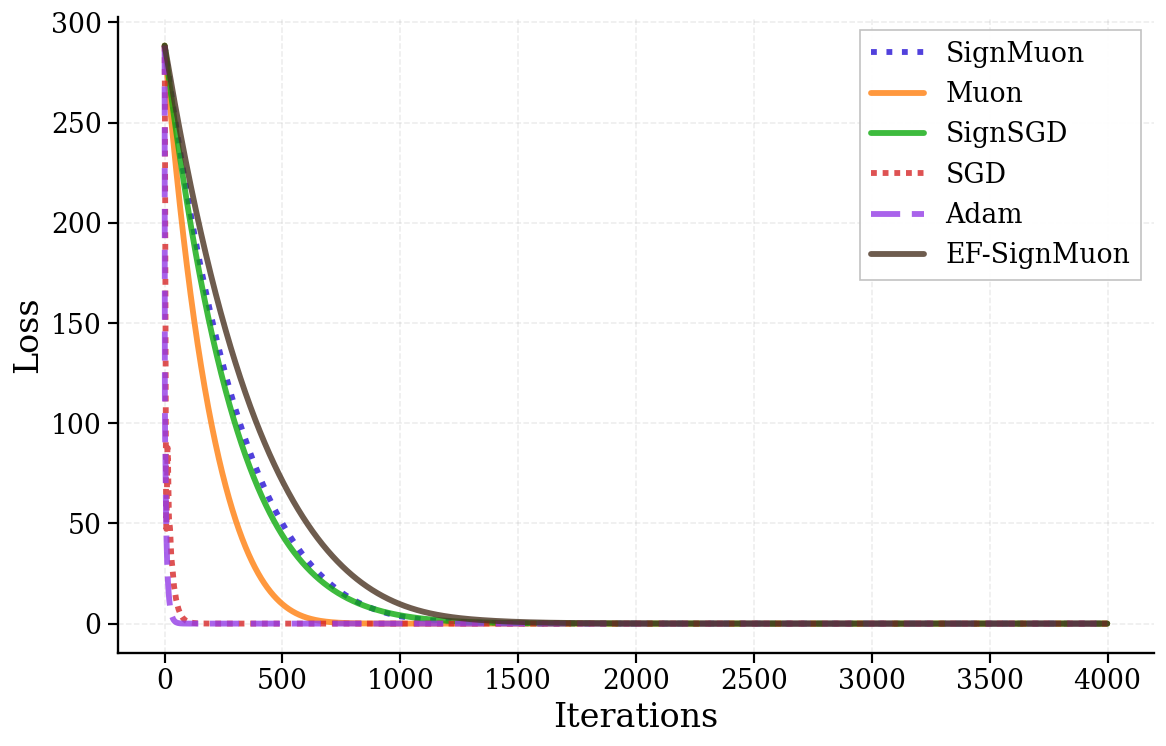

In [241]:
plot_multiple_histories(
    run_dirs=[
        "saves_synthetic_001/SignMuon",
        "saves_synthetic_001/Muon",
        "saves_synthetic_001/SignSGD",
        "saves_synthetic_001/SGD",
        "saves_synthetic_001/Adam",
        "saves_synthetic_001/EFSignMuon",
    ],
    labels=[
        "SignMuon",
        "Muon",
        "SignSGD",
        "SGD",
        "Adam",
        "EF-SignMuon",
    ],
    metric="loss_history",
        title="",
    target_loss=0.001,
    max_iterations=5000,
    save_path="im_synt/loss"
)

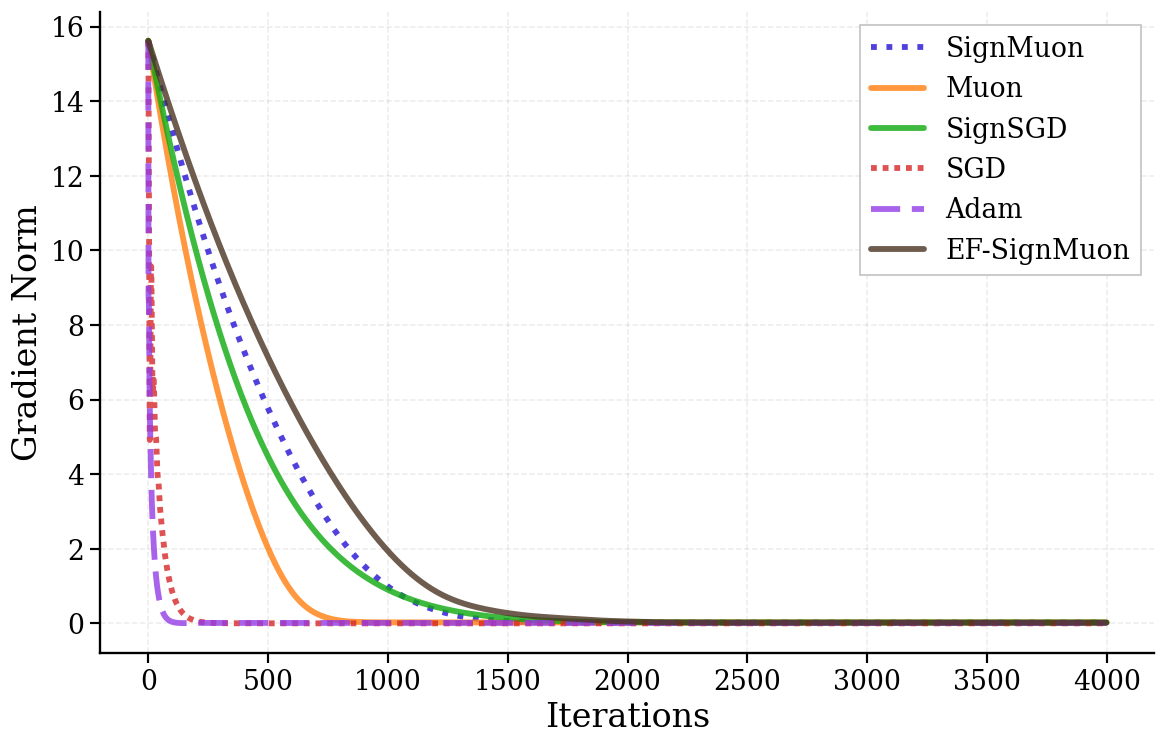

In [242]:
plot_multiple_histories(
    run_dirs=[
        "saves_synthetic_001/SignMuon",
        "saves_synthetic_001/Muon",
        "saves_synthetic_001/SignSGD",
        "saves_synthetic_001/SGD",
        "saves_synthetic_001/Adam",
        "saves_synthetic_001/EFSignMuon",
    ],
    labels=[
        "SignMuon",
        "Muon",
        "SignSGD",
        "SGD",
        "Adam",
        "EF-SignMuon",
    ],
    metric="grad_norm_history",
    title="",
    target_loss=0.001,
    max_iterations=5000,
    # line_styles=["-", "--", "-.", ":", "-"],
    save_path="im_synt/GN"
)